# Mutual Fund Analytics Dashboard

## Notebook 3 : Exploratory Data Analysis (EDA)

### Objective

Explore the cleaned mutual fund dataset to discover trends, compare fund performance, analyze fund houses, and generate business insights.

### Business Goal

Help investors and management understand mutual fund performance using descriptive analytics and visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

In [2]:
df = pd.read_csv("../data_cleaned/cleaned_mutual_funds_data.csv")

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,scheme_code,scheme_name,fund_house,scheme_type,scheme_category,net_asset_value,date,year
0,100027,Grindlays Super Saver Income Fund-GSSIF-Half Y...,Standard Chartered Mutual Fund,Open Ended Schemes,Income,10.7205,2008-05-29,2008
1,100028,Grindlays Super Saver Income Fund-GSSIF-Quater...,Standard Chartered Mutual Fund,Open Ended Schemes,Income,10.6191,2008-05-29,2008
2,100029,Grindlays Super Saver Income Fund-GSSIF-Growth,Standard Chartered Mutual Fund,Open Ended Schemes,Income,18.9736,2008-05-29,2008
3,100030,Grindlays Super Saver Income Fund-GSSIF-Annual...,Standard Chartered Mutual Fund,Open Ended Schemes,Income,10.7115,2008-05-29,2008
4,100031,Grindlays Super Saver Income Fund-GSSIF - ST-D...,Standard Chartered Mutual Fund,Open Ended Schemes,Income,10.1053,2008-05-29,2008


In [3]:
df["date"] = pd.to_datetime(df["date"])

In [4]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.info()

Rows : 35559
Columns : 8
<class 'pandas.DataFrame'>
RangeIndex: 35559 entries, 0 to 35558
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   scheme_code      35559 non-null  int64         
 1   scheme_name      35559 non-null  str           
 2   fund_house       35559 non-null  str           
 3   scheme_type      35559 non-null  str           
 4   scheme_category  35559 non-null  str           
 5   net_asset_value  35559 non-null  float64       
 6   date             35559 non-null  datetime64[us]
 7   year             35559 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 6.2 MB


In [5]:
print("Number of Fund Houses:", df["fund_house"].nunique())

Number of Fund Houses: 71


In [6]:
top_amc = (
    df["fund_house"]
    .value_counts()
    .head(10)
)

top_amc

fund_house
HDFC Mutual Fund                     3265
UTI Mutual Fund                      3209
ICICI Prudential Mutual Fund         3161
Aditya Birla Sun Life Mutual Fund    2512
SBI Mutual Fund                      1833
Reliance Mutual Fund                 1704
Kotak Mahindra Mutual Fund           1357
DSP Mutual Fund                      1326
Tata Mutual Fund                     1193
Sundaram Mutual Fund                 1134
Name: count, dtype: int64

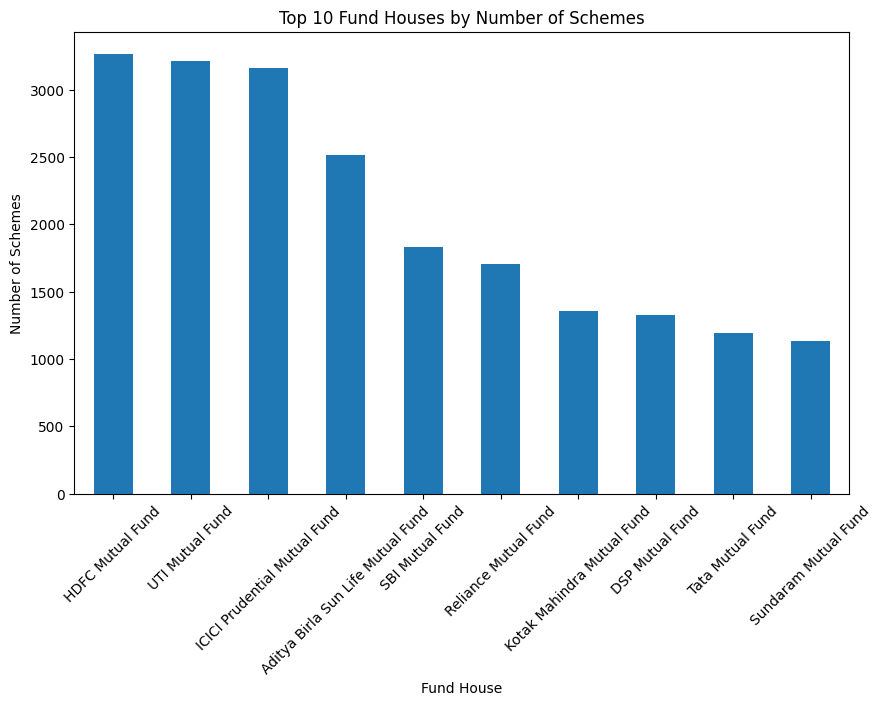

In [7]:
plt.figure(figsize=(10,6))

top_amc.plot(kind="bar")

plt.title("Top 10 Fund Houses by Number of Schemes")

plt.xlabel("Fund House")

plt.ylabel("Number of Schemes")

plt.xticks(rotation=45)

plt.show()

In [8]:
top_category = (
    df["scheme_category"]
    .value_counts()
    .head(10)
)

top_category

scheme_category
Income                                     19676
IDF                                         3947
Formerly Known as IIFL Mutual Fund          1664
1099 Days                                    991
1                                            812
Other Scheme - Index Funds                   720
Growth                                       525
Debt Scheme - Low Duration Fund              408
Debt Scheme - Ultra Short Duration Fund      363
Debt Scheme - Short Duration Fund            336
Name: count, dtype: int64

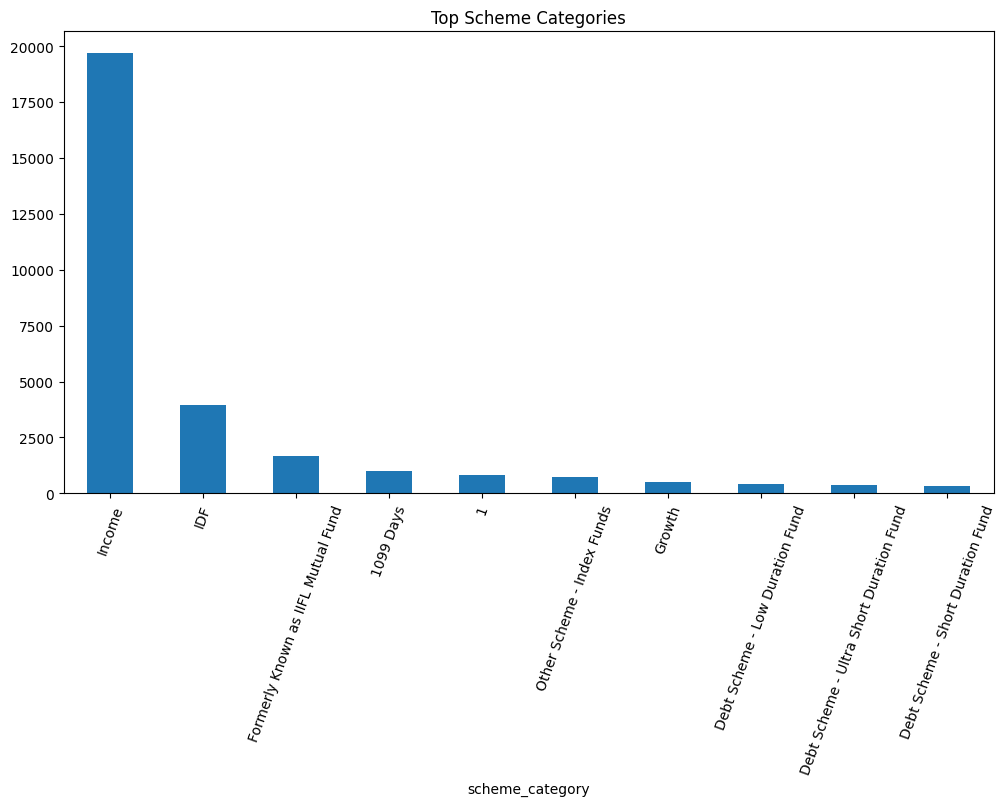

In [9]:
plt.figure(figsize=(12,6))

top_category.plot(kind="bar")

plt.title("Top Scheme Categories")

plt.xticks(rotation=70)

plt.show()

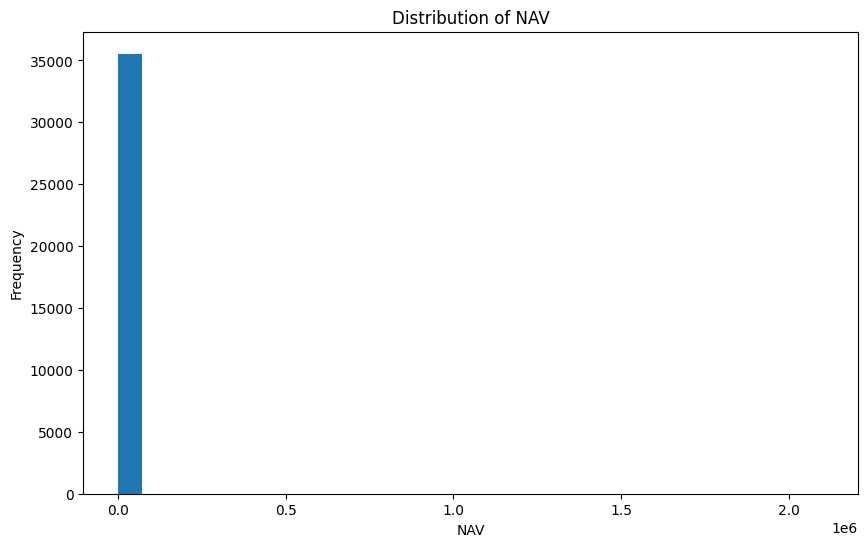

In [10]:
plt.figure(figsize=(10,6))

plt.hist(df["net_asset_value"], bins=30)

plt.title("Distribution of NAV")

plt.xlabel("NAV")

plt.ylabel("Frequency")

plt.show()

In [11]:
top_scheme = (
    df.sort_values(
        by="net_asset_value",
        ascending=False
    )
    [["scheme_name","net_asset_value"]]
    .head(10)
)

top_scheme

,scheme_name,net_asset_value
22465,IL&FS Infrastructure Debt Fund Series 1C- Divi...,2102569.015
21594,IL&FS Infrastructure Debt Fund Series 1C - Growth,2102569.014
22463,IL&FS Infrastructure Debt Fund Series 1A - Div...,1680494.046
21593,IL&FS Infrastructure Debt Fund Series 1A - Growth,1680494.046
29278,IL&FS Infrastructure Debt Fund Series 3B - Gro...,1524925.872
29279,IL&FS Infrastructure Debt Fund Series 3B - Div...,1524925.858
20411,IIFCL MUTUAL FUND INFRASTRUCTURE DEBT FUND SER...,1514458.121
22464,IL&FS Infrastructure Debt Fund Series 1B - Div...,1456756.897
21592,IL&FS Infrastructure Debt Fund Series 1B - Growth,1456756.897
32873,IL&FS Infrastructure Debt Fund Series 2B - Gro...,1409452.353


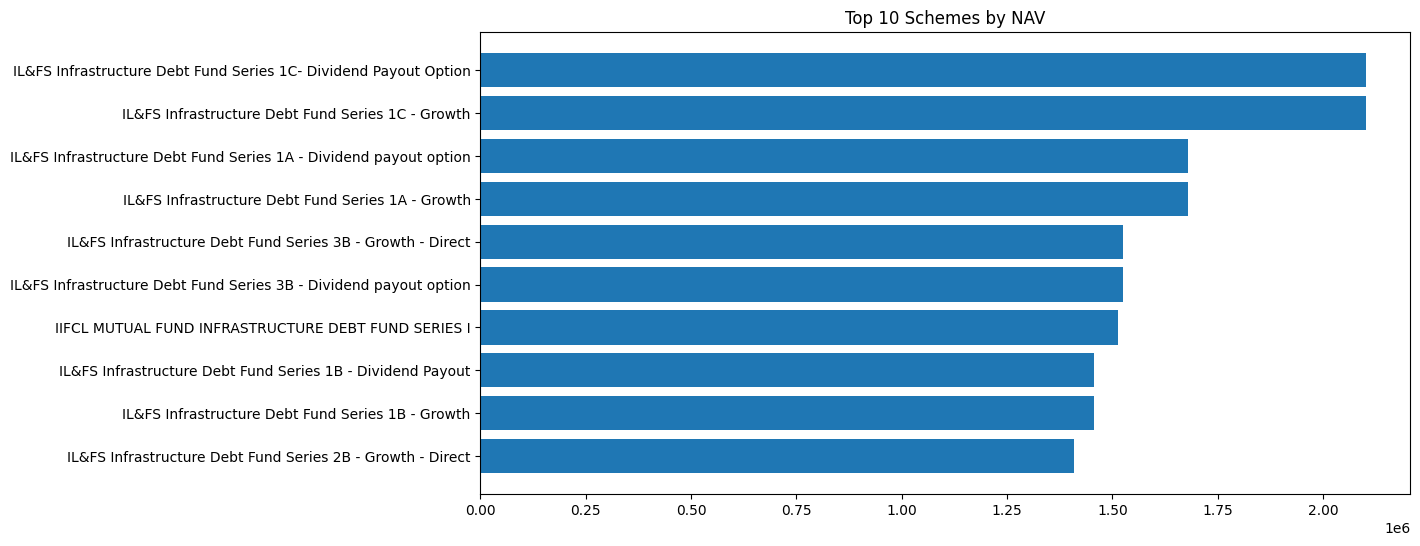

In [12]:
plt.figure(figsize=(12,6))

plt.barh(
    top_scheme["scheme_name"],
    top_scheme["net_asset_value"]
)

plt.title("Top 10 Schemes by NAV")

plt.gca().invert_yaxis()

plt.show()

In [13]:
avg_nav = (
    df.groupby("fund_house")["net_asset_value"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

avg_nav

fund_house
IDFC Mutual Fund                10205.518653
ICICI Prudential Mutual Fund     4330.876924
Trust Mutual Fund                1068.770322
YES Mutual Fund                  1001.597700
Helios Mutual Fund               1000.705350
PineBridge Mutual Fund            855.199125
Bajaj Finserv Mutual Fund         783.060288
Indiabulls Mutual Fund            777.185396
Shinsei Mutual Fund               771.603017
Daiwa Mutual Fund                 728.018950
Name: net_asset_value, dtype: float64

In [14]:
scheme_type = df["scheme_type"].value_counts()

scheme_type

scheme_type
Close Ended Schemes                                                                         16754
Open Ended Schemes                                                                          10533
IL&FS Mutual Fund                                                                            3945
360 ONE Mutual Fund                                                                          1664
135488;INF174K01Y15;-;Kotak FMP Series 180                                                    987
                                                                                            ...  
138951;INF223JA1263;-;DHFL Pramerica Mid Cap Fund - Series 1 - Regular Plan - Dividend          1
138985;INF223JA1AR0;-;DHFL Pramerica Large Cap Fund - Series 1 - Direct Plan - Dividend         1
138988;INF223JA1AP4;-;DHFL Pramerica Large Cap Fund - Series 1 - Regular Plan - Dividend        1
139020;INF223JA1FT5;-;DHFL Pramerica Large Cap Fund - Series 3 - Direct Plan - Dividend         1
139018;I

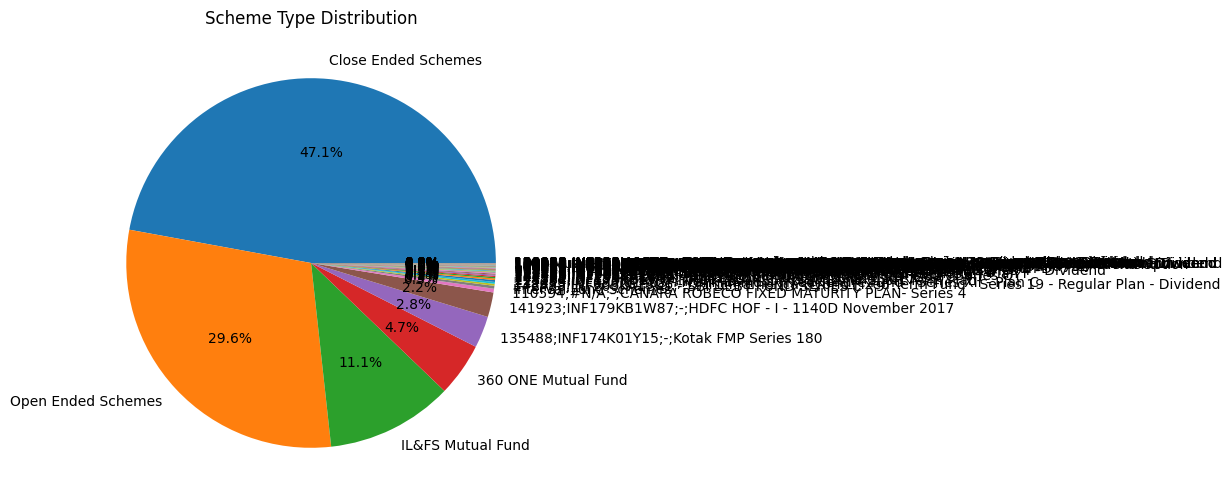

In [15]:
plt.figure(figsize=(6,6))

plt.pie(
    scheme_type,
    labels=scheme_type.index,
    autopct="%1.1f%%"
)

plt.title("Scheme Type Distribution")

plt.show()

In [16]:
df["Year"] = df["date"].dt.year

In [17]:
year_data = df["Year"].value_counts().sort_index()

year_data

Year
2006     391
2007    1109
2008    2117
2009    1856
2010     710
2011    1064
2012    1494
2013    1617
2014    2295
2015    1435
2016    2107
2017    2555
2018    2189
2019    1403
2020    1381
2021    2194
2022    1962
2023    7680
Name: count, dtype: int64

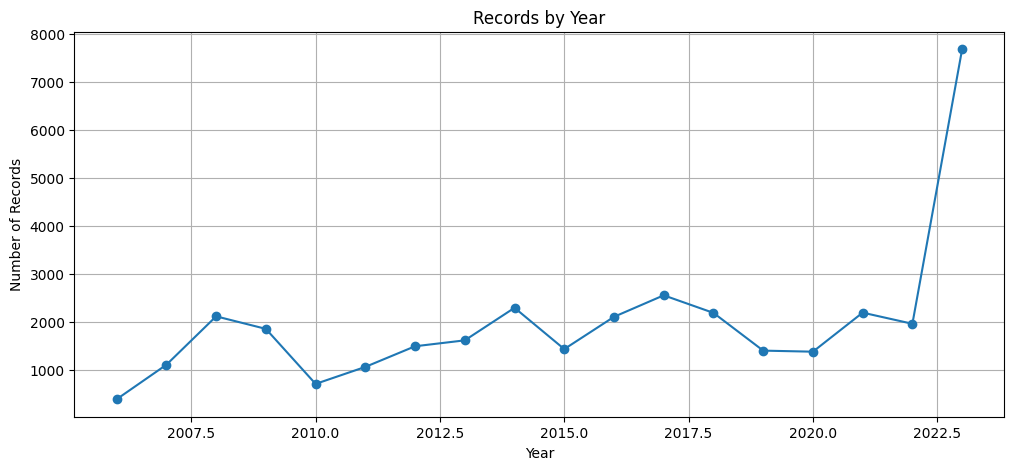

In [18]:
plt.figure(figsize=(12,5))

plt.plot(
    year_data.index,
    year_data.values,
    marker="o"
)

plt.title("Records by Year")

plt.xlabel("Year")

plt.ylabel("Number of Records")

plt.grid(True)

plt.show()

## Key Insights

- The dataset contains XX fund houses.
- Open-ended schemes dominate the market.
- Some AMCs manage significantly more schemes than others.
- NAV values are highly skewed.
- Equity and debt categories have the largest number of schemes.
- The cleaned dataset is suitable for SQL analysis and dashboard creation.